<img align="left" style="padding-right:10px;" src="figuras/banner_cd.png">

# Proyecto de Machine Learning

## 0. Librerias Generales

In [1]:
# Importar librerias
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np

## 1. Obtención y visualización de los datos

In [40]:
df = pd.read_csv('datos/Datos_Train-Validation.csv')
df

,id,CustomerId,Surname,CreditScore,Gender-0Male-1Female,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,0,33,3,0.00,2,1,0,181449.97,0
1,1,15749177,Okwudiliolisa,627,0,33,1,0.00,2,1,1,49503.50,0
2,2,15694510,Hsueh,678,0,40,10,0.00,2,1,0,184866.69,0
3,3,15741417,Kao,581,0,34,2,148882.54,1,1,1,84560.88,0
4,4,15766172,Chiemenam,716,0,33,5,0.00,2,1,1,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,15773776,K?,691,0,30,7,0.00,1,1,0,149991.32,0
9996,9996,15674720,Smith,667,1,37,7,123067.63,1,0,1,98162.44,0
9997,9997,15757628,Hsieh,791,0,35,4,80793.58,1,1,0,28188.96,0
9998,9998,15662404,Nwachinemelu,619,0,46,4,0.00,2,1,0,149991.71,0


## 2. Preparación de los datos y funciones

In [41]:
# Preparación de datos
from sklearn.model_selection import train_test_split

In [43]:
## Verificando que no existan valores nulos
df.isnull().any().any()

np.False_

#### División general de los datos


* **X**: Datos sin el diagnostico es decir sin la columna "target"
* **y**: Datos con el diagnostico es decir con la columna "target"

Muestras de entrenamiento y prueba
* **X_train**: este será el grupo de entrenamiento
* **X_test**: este será el  grupo de prueba
* **y_train**: este será el target para el grupo de entrenamiento
* **y_test**: este será el target para el grupo de prueba

In [44]:
#Crear X (Quitar la columna o campo 24)
X =df.drop(['id','CustomerId','Surname','Exited'], axis=1)
X.head(2)

,CreditScore,Gender-0Male-1Female,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,668,0,33,3,0.0,2,1,0,181449.97
1,627,0,33,1,0.0,2,1,1,49503.50


In [45]:
# Crear y (Valor de de la columna "target")
y=df['Exited']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Exited, dtype: int64

In [46]:
df

,id,CustomerId,Surname,CreditScore,Gender-0Male-1Female,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,0,33,3,0.00,2,1,0,181449.97,0
1,1,15749177,Okwudiliolisa,627,0,33,1,0.00,2,1,1,49503.50,0
2,2,15694510,Hsueh,678,0,40,10,0.00,2,1,0,184866.69,0
3,3,15741417,Kao,581,0,34,2,148882.54,1,1,1,84560.88,0
4,4,15766172,Chiemenam,716,0,33,5,0.00,2,1,1,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,15773776,K?,691,0,30,7,0.00,1,1,0,149991.32,0
9996,9996,15674720,Smith,667,1,37,7,123067.63,1,0,1,98162.44,0
9997,9997,15757628,Hsieh,791,0,35,4,80793.58,1,1,0,28188.96,0
9998,9998,15662404,Nwachinemelu,619,0,46,4,0.00,2,1,0,149991.71,0


In [47]:
# Dividir los datos para entrenamiento y prueba. Con un factor 80%
X_train , X_test, y_train, y_test = train_test_split(X, y, train_size=0.82, random_state=4)
print( 'X_train :' , X_train.shape )
print( 'X_test :' , X_test.shape )
print( 'y_train :' , y_train.shape )
print( 'y_test :' ,  y_test.shape )
print( 'df 100% :' ,  df.shape[0]   )
print( 'len(X_train) / 3 :' ,  len(X_train) / 3 )


X_train : (8200, 9)
X_test : (1800, 9)
y_train : (8200,)
y_test : (1800,)
df 100% : 10000
len(X_train) / 3 : 2733.3333333333335


### Pipeline

<img src="figuras/pipeline.jpg" align="middle" style="width:400px;" />

In [48]:
# Modulos importantes
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [50]:
# Mostrando columnas
X.columns

Index(['CreditScore', 'Gender-0Male-1Female', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [51]:
# Crear la lista de  viriables numericas  numeric_list 
numeric_list = ['CreditScore', 'Gender-0Male-1Female', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

In [52]:
# Crear el pipeline de preprocesamiento para datos numéricos  numeric_transformer
numeric_transformer = Pipeline(  steps = [ ('scaler',  StandardScaler()  )  ]   )

In [53]:
# Definir los transformadores
transformer = ColumnTransformer( [ ('num', numeric_transformer, numeric_list  )  ]  )

# 3. Implementación de Modelos

## Tercer modelo: Random Forest

Referencias generales
* https://www.learndatasci.com/glossary/binary-classification/
* https://scikit-learn.org/stable/modules/grid_search.html

Referencia RF
* https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74

## a) RF sin tunning

In [54]:
# Módulos del Modelo
#from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score


In [55]:
# modelo 
from sklearn.ensemble import RandomForestClassifier

RF_Classifier =  RandomForestClassifier()

In [56]:
# Parametros del modelo DecisionTreeClassifier()
RF_Classifier.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [57]:
# Definiendo el modelo_DT con su pipeline
modelo_RF = Pipeline(  [ ('transformer', transformer) , 
                        ('RF_Classifier',RF_Classifier)    ]  )

In [58]:
# Ajuste del modelo
modelo_RF.fit(X_train, y_train)

,steps,"[('transformer', ...), ('RF_Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [59]:
# Score sin tunning
modelo_RF.score(X_test, y_test)

0.8422222222222222

## b) RF con tunning

In [60]:
# Definir los parametros con el diccionario params utilizando:


n_estimators= [10,15,20, 30, 50,100,150,200]
max_depth= [4,8,12 ]
min_samples_split= [2,6,8]
 

params = { 'RF_Classifier__n_estimators' : n_estimators,
         'RF_Classifier__max_depth': max_depth,
         'RF_Classifier__min_samples_split': min_samples_split }



In [61]:
# Ajuste de los parametros max_depth y min_samples_leaf con  GridSearchCV
from sklearn.model_selection import GridSearchCV

grid_RF = GridSearchCV(modelo_RF, 
                       param_grid= params,
                      cv=5,
                      n_jobs=-1,
                      verbose=10)

In [62]:
# Ajuste del modelo usando todas las posibles combinaciones de parámetros 
grid_RF.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


[CV 1/5; 1/72] START RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=10
[CV 1/5; 1/72] END RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=10;, score=0.843 total time=   0.1s
[CV 2/5; 1/72] START RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=10
[CV 2/5; 1/72] END RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=10;, score=0.854 total time=   0.1s
[CV 5/5; 1/72] START RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=10
[CV 4/5; 2/72] START RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=15
[CV 5/5; 1/72] END RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifier__n_estimators=10;, score=0.837 total time=   0.1s
[CV 4/5; 2/72] END RF_Classifier__max_depth=4, RF_Classifier__min_samples_split=2, RF_Classifie

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'RF_Classifier__max_depth': [4, 8, ...], 'RF_Classifier__min_samples_split': [2, 6, ...], 'RF_Classifier__n_estimators': [10, 15, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [63]:
#Encontrar los mejores parametros con best_params_
grid_RF.best_params_

{'RF_Classifier__max_depth': 8,
 'RF_Classifier__min_samples_split': 2,
 'RF_Classifier__n_estimators': 150}

In [64]:
# Ajustar el modelo con los nuevos parámetros  
RF_Classifier_tunned =  RandomForestClassifier(max_depth= 8, min_samples_split =2 , n_estimators = 150 )

In [65]:
# Definiendo el modelo_DT con su pipeline
modelo_RF_tunned = Pipeline(  [ ('transformer', transformer) , 
                        ('RF_Classifier_tunned',RF_Classifier_tunned)    ]  )

In [66]:
#  Ajustar el modelo
modelo_RF_tunned.fit(X_train, y_train)

,steps,"[('transformer', ...), ('RF_Classifier_tunned', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
# Predicción
y_predict = modelo_RF_tunned.predict(X_test)
y_predict

array([0, 1, 0, ..., 1, 0, 0], shape=(1800,))

In [68]:
# Prueba en y_test
y_test.values

array([0, 1, 0, ..., 1, 0, 0], shape=(1800,))

In [69]:
# Comparación
#np.equal(  y_predict , y_test.values ) 

In [70]:
# Score
np.equal(  y_predict , y_test.values  ).sum()/ len(y_predict)

np.float64(0.8544444444444445)

In [71]:
# Score
modelo_RF_tunned.score(X_test, y_test)

0.8544444444444445

### Guardar el modelo entrenado

In [72]:
import joblib

In [73]:
#Exportar el modelo
#joblib.dump(modelo, 'Ubicación del archivo .joblib')
joblib.dump(modelo_RF_tunned, 'modelos/modelo_RF_tunned_Semilla.joblib')

['modelos/modelo_RF_tunned_Semilla.joblib']

In [74]:
# Importar librerias
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score

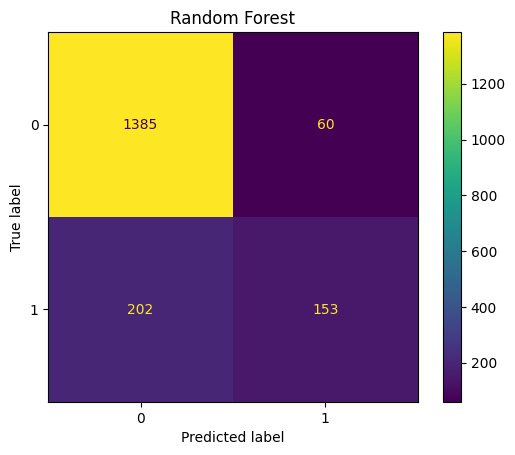

In [75]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions_DT_tunned = modelo_RF_tunned.predict(X_test)
cm_DT_tunned = confusion_matrix(y_test, predictions_DT_tunned, labels=modelo_RF_tunned.classes_)
disp_DT_tunned  = ConfusionMatrixDisplay(confusion_matrix=cm_DT_tunned, display_labels=modelo_RF_tunned.classes_)
disp_DT_tunned.plot()
plt.title('Random Forest')
plt.show()